## Step 1: Load Copula Parameters and Prepare for Batch Backtesting

We will loop through all 11 copula-fitted stock pairs, apply the same trading logic, and evaluate performance consistently.

In [8]:
import pandas as pd

# Load copula parameters
copula_df = pd.read_csv("t_copula_params.csv")

# Load log returns
log_returns = pd.read_csv("log_returns.csv", index_col=0, parse_dates=True)

# Inspect first few copula pairs
display(copula_df.head())

# Optional: define threshold bounds (static for all pairs)
lower_bound = 0.05
upper_bound = 0.95

,Stock A,Stock B,t-Copula ρ,t-Copula ν,Log-Likelihood
0,MA,V,0.848479,5.0,-3895.437307
1,FRT,KIM,0.871350,5.0,-3978.578323
2,MCO,SPGI,0.857499,5.0,-3935.623231
3,AVB,ESS,0.881004,5.0,-3987.302389
4,DHI,LEN,0.936654,5.0,-4230.268894


## Step 2: Define Helper Functions for Simulation and Strategy Evaluation

We define functions for simulating from the t-copula, generating signals based on ECDF-transformed marginals, and computing strategy performance metrics.

In [20]:
from scipy.stats import t as student_t
from scipy.stats import norm, rankdata
from scipy.stats import multivariate_t
import numpy as np

# Simulate from t-Copula
def simulate_t_copula(rho, df, n_samples=10000):
    cov = np.array([[1, rho], [rho, 1]])
    mean = np.zeros(2)
    samples = multivariate_t.rvs(loc=mean, shape=cov, df=df, size=n_samples)
    
    u_sim = student_t.cdf(samples[:, 0], df)
    v_sim = student_t.cdf(samples[:, 1], df)
    
    return u_sim, v_sim

# ECDF transformation
def ecdf_transform(series):
    ranks = rankdata(series, method='ordinal')
    return pd.Series(ranks / (len(series) + 1), index=series.index)

# Strategy metrics
def compute_metrics(signal_df):
    daily_returns = signal_df["Strategy Return"]
    sharpe = np.sqrt(252) * daily_returns.mean() / daily_returns.std()
    win_rate = (daily_returns > 0).sum() / len(daily_returns)

    cum_returns = signal_df["Cumulative Return"]
    roll_max = cum_returns.cummax()
    drawdown = (cum_returns - roll_max) / roll_max
    max_drawdown = drawdown.min()

    return sharpe, win_rate, max_drawdown

### Step 3: Run Backtest Across All Copula Pairs

We loop through all 11 copula-fitted stock pairs and apply the full trading strategy, evaluating its performance using Sharpe Ratio, Win Rate, Max Drawdown, and Final Return.

In [28]:
# Prepare results container
results = []

# Loop through all copula pairs
pair_results = {}
for i, row in copula_df.iterrows():
    stock_a = row["Stock A"]
    stock_b = row["Stock B"]
    rho = row["t-Copula ρ"]
    df_t = row["t-Copula ν"]

    # Skip if data missing
    if stock_a not in log_returns.columns or stock_b not in log_returns.columns:
        continue

    # Step 1: Simulate from fitted t-copula
    u_sim, v_sim = simulate_t_copula(rho, df_t)

    # Step 2: Calculate signal thresholds
    u_lower, u_upper = np.quantile(u_sim, [lower_bound, upper_bound])
    v_lower, v_upper = np.quantile(v_sim, [lower_bound, upper_bound])

    # Step 3: Apply ECDF transform to historical data
    u_hist = ecdf_transform(log_returns[stock_a].dropna())
    v_hist = ecdf_transform(log_returns[stock_b].dropna())
    common_idx = u_hist.index.intersection(v_hist.index)
    u_hist = u_hist.loc[common_idx]
    v_hist = v_hist.loc[common_idx]

    # Step 4: Generate signals
    signals = []
    for u, v in zip(u_hist, v_hist):
        if u < u_lower or v < v_lower:
            signals.append(1)   # Long A, Short B
        elif u > u_upper or v > v_upper:
            signals.append(-1)  # Short A, Long B
        else:
            signals.append(0)

    # Step 5: Create strategy DataFrame
    signal_df = pd.DataFrame({
        stock_a: log_returns[stock_a].loc[common_idx],
        stock_b: log_returns[stock_b].loc[common_idx],
        "Signal": signals
    })

    # Compute spread and strategy returns
    signal_df["Lagged Signal"] = signal_df["Signal"].shift(1)
    signal_df["Spread Return"] = signal_df[stock_a] - signal_df[stock_b]
    signal_df["Strategy Return"] = signal_df["Lagged Signal"] * signal_df["Spread Return"]
    signal_df.dropna(inplace=True)
    signal_df["Cumulative Return"] = (1 + signal_df["Strategy Return"]).cumprod()

    # Evaluate metrics
    sharpe, win_rate, max_dd = compute_metrics(signal_df)

    # Store results
    pair_results[f"{stock_a}-{stock_b}"] = signal_df.copy()
    results.append({
        "Pair": f"{stock_a}-{stock_b}",
        "Sharpe Ratio": sharpe,
        "Win Rate": win_rate,
        "Max Drawdown": max_dd,
        "Final Return": signal_df["Cumulative Return"].iloc[-1]
    })

In [24]:
# Step 6: Display All Strategy Results

results_df = pd.DataFrame(results)
display(results_df.sort_values("Final Return", ascending=False))

,Pair,Sharpe Ratio,Win Rate,Max Drawdown,Final Return
10,HAL-SLB,0.651868,0.073333,-0.102225,1.197541
7,CMS-DTE,1.183119,0.078667,-0.046838,1.135854
3,AVB-ESS,0.772881,0.066667,-0.047872,1.125424
5,LEN-PHM,0.314461,0.077333,-0.111718,1.054517
9,ED-WEC,0.167332,0.072000,-0.069538,1.018265
0,MA-V,-0.000620,0.065333,-0.110899,0.997098
8,AEE-WEC,-0.066524,0.061333,-0.066185,0.986653
2,MCO-SPGI,-0.042888,0.072000,-0.119928,0.986491
4,DHI-LEN,-0.149705,0.061333,-0.068664,0.976775
1,FRT-KIM,-0.203529,0.065333,-0.082658,0.967867


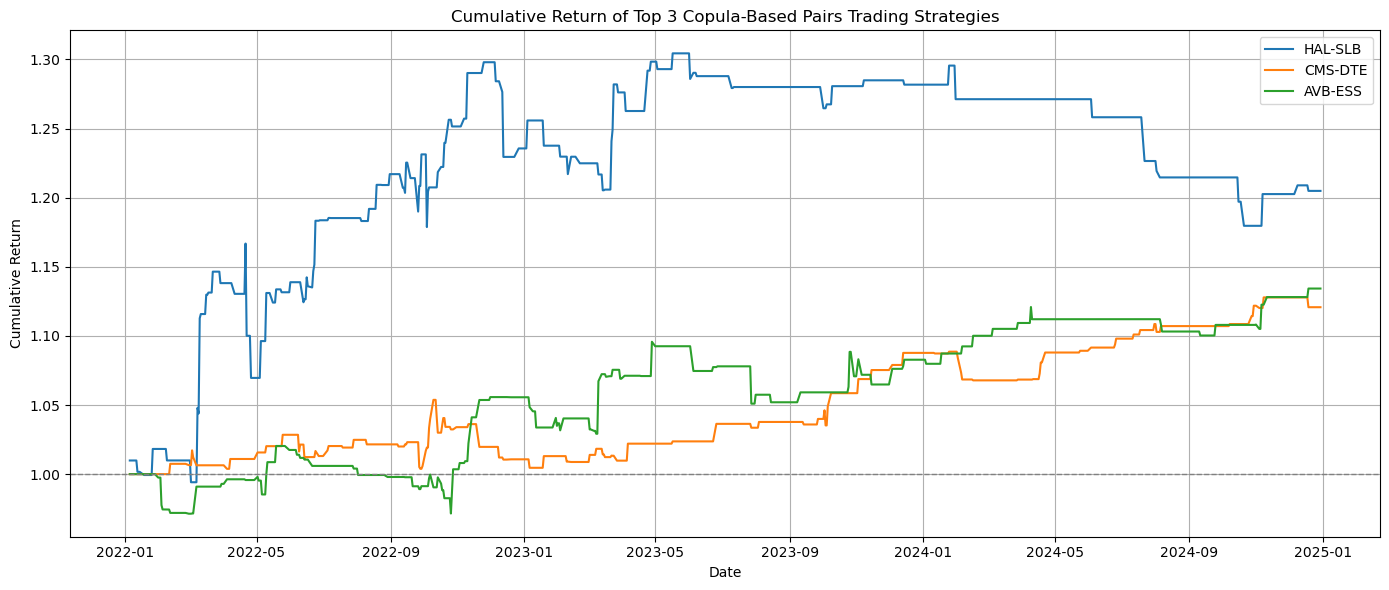

In [38]:
import matplotlib.pyplot as plt

# List of top 3 pairs
top_pairs = ["HAL-SLB", "CMS-DTE", "AVB-ESS"]

# Plot cumulative returns
plt.figure(figsize=(14, 6))

for pair in top_pairs:
    signal_df = pair_results[pair]  # Assuming this dict contains all signal_dfs
    plt.plot(signal_df.index, signal_df["Cumulative Return"], label=pair)

plt.axhline(1.0, color='gray', linestyle='--', linewidth=1)
plt.title("Cumulative Return of Top 3 Copula-Based Pairs Trading Strategies")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()